Lecture 2 — Class Exercise
Bar Charts: World Happiness Report 2023

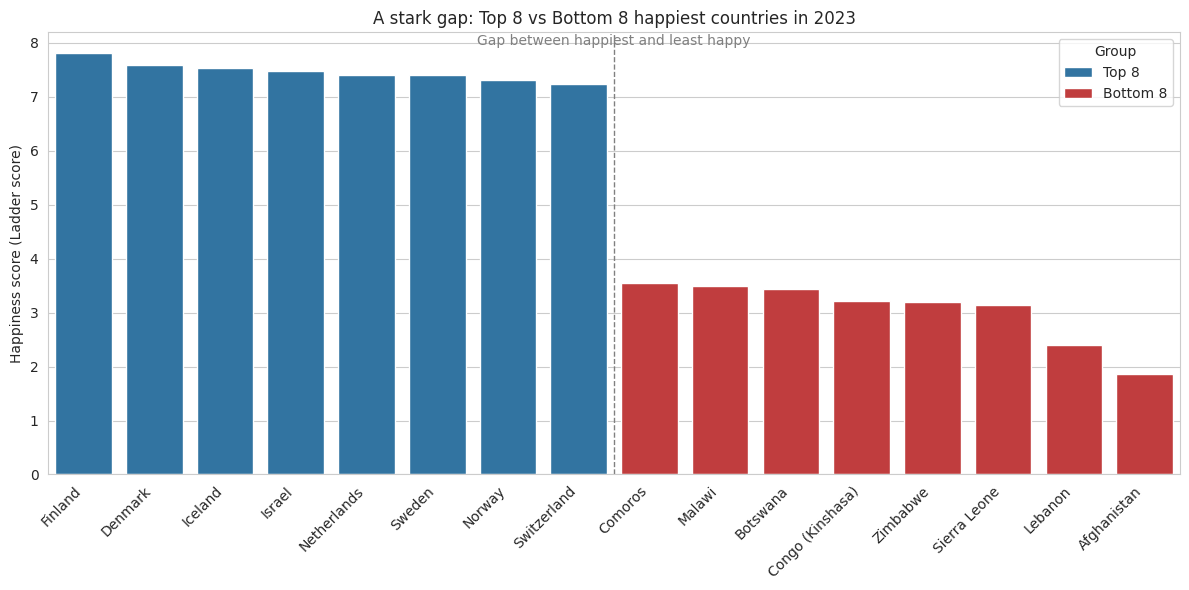

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/bin/WHR2023.csv')

# Sort by happiness (Ladder score)
df_sorted = df.sort_values('Ladder score', ascending=False)

top8 = df_sorted.head(8).copy()
bottom8 = df_sorted.tail(8).copy()

top8['Group'] = 'Top 8'
bottom8['Group'] = 'Bottom 8'

gap_df = pd.concat([top8, bottom8], axis=0)

# Order: top 8 (best to worst), then bottom 8 (worst to best)
gap_df['Order'] = range(len(gap_df))
gap_df = gap_df.sort_values(['Group', 'Ladder score'], ascending=[False, False])

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

palette = {'Top 8': '#1f77b4', 'Bottom 8': '#d62728'}

bars = sns.barplot(
    data=gap_df,
    x='Country name',
    y='Ladder score',
    hue='Group',
    palette=palette,
    dodge=False
)

# Visual separator between top and bottom groups
plt.axvline(x=7.5, color='gray', linestyle='--', linewidth=1)
plt.text(7.5, gap_df['Ladder score'].max() + 0.1,
         'Gap between happiest and least happy',
         ha='center', va='bottom', color='gray', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Happiness score (Ladder score)')
plt.xlabel('')
plt.legend(title='Group')

# Insightful title
plt.title('A stark gap: Top 8 vs Bottom 8 happiest countries in 2023')

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv('/bin/WHR2023.csv')

# --- REGION MAPPING (required because dataset has no region column) ---
region_map = {
    'Finland':'Western Europe','Denmark':'Western Europe','Iceland':'Western Europe','Israel':'Middle East',
    'Netherlands':'Western Europe','Sweden':'Western Europe','Norway':'Western Europe','Switzerland':'Western Europe',
    'Luxembourg':'Western Europe','New Zealand':'Australia & NZ','Austria':'Western Europe',
    'Australia':'Australia & NZ','Canada':'North America','Ireland':'Western Europe',
    'United States':'North America','Germany':'Western Europe','Belgium':'Western Europe','Czechia':'Central Europe',
    'United Kingdom':'Western Europe','Lithuania':'Central Europe','France':'Western Europe','Slovenia':'Central Europe',
    'Costa Rica':'Latin America','Romania':'Central Europe','Singapore':'East Asia','United Arab Emirates':'Middle East',
    'Taiwan Province of China':'East Asia','Uruguay':'Latin America','Slovakia':'Central Europe','Saudi Arabia':'Middle East',
    'Estonia':'Central Europe','Spain':'Western Europe','Italy':'Western Europe','Kosovo':'Central Europe',
    'Chile':'Latin America','Mexico':'Latin America','Malta':'Western Europe','Panama':'Latin America',
    'Poland':'Central Europe','Nicaragua':'Latin America','Latvia':'Central Europe','Bahrain':'Middle East',
    'Guatemala':'Latin America','Kazakhstan':'Central Asia','Serbia':'Central Europe','Cyprus':'Middle East',
    'Japan':'East Asia','Croatia':'Central Europe','Brazil':'Latin America','El Salvador':'Latin America',
    'Hungary':'Central Europe','Argentina':'Latin America','Honduras':'Latin America','Uzbekistan':'Central Asia',
    'Malaysia':'East Asia','Portugal':'Western Europe','South Korea':'East Asia','Greece':'Western Europe',
    'Mauritius':'Sub-Saharan Africa','Thailand':'East Asia','Mongolia':'East Asia','Kyrgyzstan':'Central Asia',
    'Moldova':'Central Europe','China':'East Asia','Vietnam':'East Asia','Paraguay':'Latin America',
    'Montenegro':'Central Europe','Jamaica':'Latin America','Bolivia':'Latin America','Russia':'Central Asia',
    'Bosnia and Herzegovina':'Central Europe','Colombia':'Latin America','Dominican Republic':'Latin America',
    'Ecuador':'Latin America','Peru':'Latin America','Philippines':'East Asia','Bulgaria':'Central Europe',
    'Nepal':'South Asia','Armenia':'Central Asia','Tajikistan':'Central Asia','Algeria':'Middle East',
    'Hong Kong S.A.R. of China':'East Asia','Albania':'Central Europe','Indonesia':'East Asia',
    'South Africa':'Sub-Saharan Africa','Congo (Brazzaville)':'Sub-Saharan Africa','North Macedonia':'Central Europe',
    'Venezuela':'Latin America','Laos':'East Asia','Georgia':'Central Asia','Guinea':'Sub-Saharan Africa',
    'Ukraine':'Central Europe','Ivory Coast':'Sub-Saharan Africa','Gabon':'Sub-Saharan Africa','Nigeria':'Sub-Saharan Africa',
    'Cameroon':'Sub-Saharan Africa','Mozambique':'Sub-Saharan Africa','Iraq':'Middle East',
    'State of Palestine':'Middle East','Morocco':'Middle East','Iran':'Middle East','Senegal':'Sub-Saharan Africa',
    'Mauritania':'Sub-Saharan Africa','Burkina Faso':'Sub-Saharan Africa','Namibia':'Sub-Saharan Africa',
    'Turkiye':'Middle East','Ghana':'Sub-Saharan Africa','Pakistan':'South Asia','Niger':'Sub-Saharan Africa',
    'Tunisia':'Middle East','Kenya':'Sub-Saharan Africa','Sri Lanka':'South Asia','Uganda':'Sub-Saharan Africa',
    'Chad':'Sub-Saharan Africa','Cambodia':'East Asia','Benin':'Sub-Saharan Africa','Myanmar':'East Asia',
    'Bangladesh':'South Asia','Gambia':'Sub-Saharan Africa','Mali':'Sub-Saharan Africa','Egypt':'Middle East',
    'Togo':'Sub-Saharan Africa','Jordan':'Middle East','Ethiopia':'Sub-Saharan Africa','Liberia':'Sub-Saharan Africa',
    'India':'South Asia','Madagascar':'Sub-Saharan Africa','Zambia':'Sub-Saharan Africa','Tanzania':'Sub-Saharan Africa',
    'Comoros':'Sub-Saharan Africa','Malawi':'Sub-Saharan Africa','Botswana':'Sub-Saharan Africa',
    'Congo (Kinshasa)':'Sub-Saharan Africa','Zimbabwe':'Sub-Saharan Africa','Sierra Leone':'Sub-Saharan Africa',
    'Lebanon':'Middle East','Afghanistan':'South Asia'
}

df["Region"] = df["Country name"].map(region_map)

# --- Compute regional averages ---
region_avg = (
    df.groupby("Region")["Ladder score"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

# --- Plotly horizontal bar chart ---
fig = px.bar(
    region_avg,
    x="Ladder score",
    y="Region",
    orientation="h",
    text="Ladder score",
    color="Ladder score",
    color_continuous_scale="Blues",
)

# Zero baseline
fig.update_layout(xaxis=dict(range=[0, region_avg["Ladder score"].max() + 0.5]))

# Clean labels
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

# Insight title
fig.update_layout(
    title=(
        "Western Europe Leads the World in Happiness — "
        "Highlighting a Persistent Regional Well‑Being Advantage"
    ),
    xaxis_title="Average Happiness Score",
    yaxis_title="Region",
    coloraxis_showscale=False,
    plot_bgcolor="white"
)

fig.show()


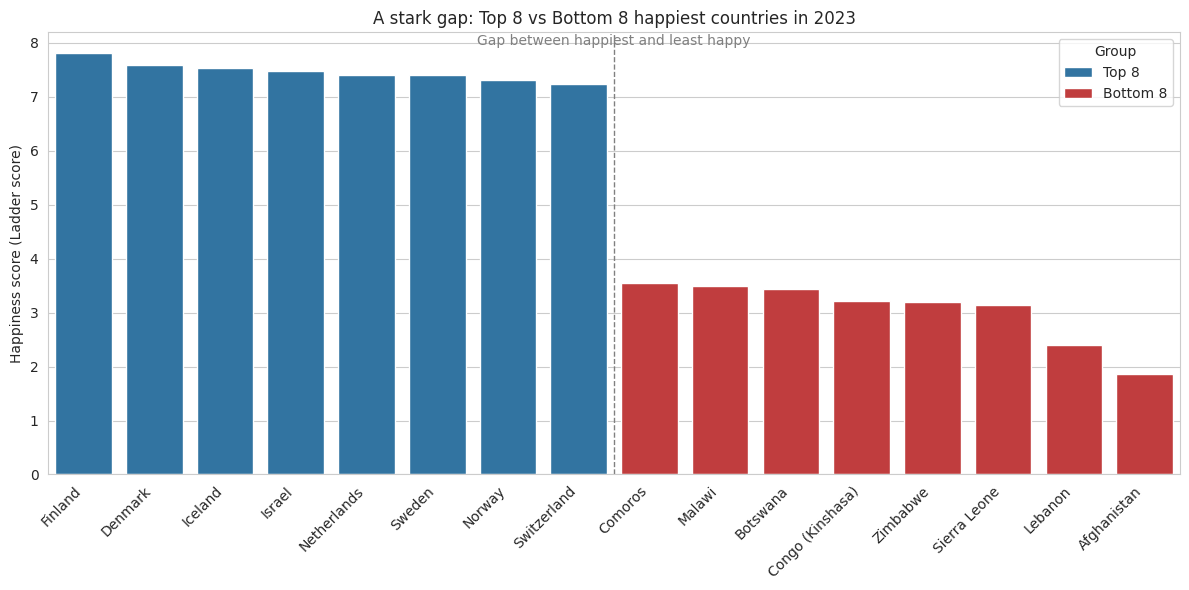

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/bin/WHR2023.csv')

# Sort by happiness (Ladder score)
df_sorted = df.sort_values('Ladder score', ascending=False)

top8 = df_sorted.head(8).copy()
bottom8 = df_sorted.tail(8).copy()

top8['Group'] = 'Top 8'
bottom8['Group'] = 'Bottom 8'

gap_df = pd.concat([top8, bottom8], axis=0)

# Order: top 8 (best to worst), then bottom 8 (worst to best)
gap_df['Order'] = range(len(gap_df))
gap_df = gap_df.sort_values(['Group', 'Ladder score'], ascending=[False, False])

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

palette = {'Top 8': '#1f77b4', 'Bottom 8': '#d62728'}

bars = sns.barplot(
    data=gap_df,
    x='Country name',
    y='Ladder score',
    hue='Group',
    palette=palette,
    dodge=False
)

# Visual separator between top and bottom groups
plt.axvline(x=7.5, color='gray', linestyle='--', linewidth=1)
plt.text(7.5, gap_df['Ladder score'].max() + 0.1,
         'Gap between happiest and least happy',
         ha='center', va='bottom', color='gray', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Happiness score (Ladder score)')
plt.xlabel('')
plt.legend(title='Group')

# Insightful title
plt.title('A stark gap: Top 8 vs Bottom 8 happiest countries in 2023')

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv('/bin/WHR2023.csv')

# --- REGION MAPPING (same mapping used earlier) ---
region_map = {
    'Finland':'Western Europe','Denmark':'Western Europe','Iceland':'Western Europe','Israel':'Middle East',
    'Netherlands':'Western Europe','Sweden':'Western Europe','Norway':'Western Europe','Switzerland':'Western Europe',
    'Luxembourg':'Western Europe','New Zealand':'Australia & NZ','Austria':'Western Europe',
    'Australia':'Australia & NZ','Canada':'North America','Ireland':'Western Europe',
    'United States':'North America','Germany':'Western Europe','Belgium':'Western Europe','Czechia':'Central Europe',
    'United Kingdom':'Western Europe','Lithuania':'Central Europe','France':'Western Europe','Slovenia':'Central Europe',
    'Costa Rica':'Latin America','Romania':'Central Europe','Singapore':'East Asia','United Arab Emirates':'Middle East',
    'Taiwan Province of China':'East Asia','Uruguay':'Latin America','Slovakia':'Central Europe','Saudi Arabia':'Middle East',
    'Estonia':'Central Europe','Spain':'Western Europe','Italy':'Western Europe','Kosovo':'Central Europe',
    'Chile':'Latin America','Mexico':'Latin America','Malta':'Western Europe','Panama':'Latin America',
    'Poland':'Central Europe','Nicaragua':'Latin America','Latvia':'Central Europe','Bahrain':'Middle East',
    'Guatemala':'Latin America','Kazakhstan':'Central Asia','Serbia':'Central Europe','Cyprus':'Middle East',
    'Japan':'East Asia','Croatia':'Central Europe','Brazil':'Latin America','El Salvador':'Latin America',
    'Hungary':'Central Europe','Argentina':'Latin America','Honduras':'Latin America','Uzbekistan':'Central Asia',
    'Malaysia':'East Asia','Portugal':'Western Europe','South Korea':'East Asia','Greece':'Western Europe',
    'Mauritius':'Sub-Saharan Africa','Thailand':'East Asia','Mongolia':'East Asia','Kyrgyzstan':'Central Asia',
    'Moldova':'Central Europe','China':'East Asia','Vietnam':'East Asia','Paraguay':'Latin America',
    'Montenegro':'Central Europe','Jamaica':'Latin America','Bolivia':'Latin America','Russia':'Central Asia',
    'Bosnia and Herzegovina':'Central Europe','Colombia':'Latin America','Dominican Republic':'Latin America',
    'Ecuador':'Latin America','Peru':'Latin America','Philippines':'East Asia','Bulgaria':'Central Europe',
    'Nepal':'South Asia','Armenia':'Central Asia','Tajikistan':'Central Asia','Algeria':'Middle East',
    'Hong Kong S.A.R. of China':'East Asia','Albania':'Central Europe','Indonesia':'East Asia',
    'South Africa':'Sub-Saharan Africa','Congo (Brazzaville)':'Sub-Saharan Africa','North Macedonia':'Central Europe',
    'Venezuela':'Latin America','Laos':'East Asia','Georgia':'Central Asia','Guinea':'Sub-Saharan Africa',
    'Ukraine':'Central Europe','Ivory Coast':'Sub-Saharan Africa','Gabon':'Sub-Saharan Africa','Nigeria':'Sub-Saharan Africa',
    'Cameroon':'Sub-Saharan Africa','Mozambique':'Sub-Saharan Africa','Iraq':'Middle East',
    'State of Palestine':'Middle East','Morocco':'Middle East','Iran':'Middle East','Senegal':'Sub-Saharan Africa',
    'Mauritania':'Sub-Saharan Africa','Burkina Faso':'Sub-Saharan Africa','Namibia':'Sub-Saharan Africa',
    'Turkiye':'Middle East','Ghana':'Sub-Saharan Africa','Pakistan':'South Asia','Niger':'Sub-Saharan Africa',
    'Tunisia':'Middle East','Kenya':'Sub-Saharan Africa','Sri Lanka':'South Asia','Uganda':'Sub-Saharan Africa',
    'Chad':'Sub-Saharan Africa','Cambodia':'East Asia','Benin':'Sub-Saharan Africa','Myanmar':'East Asia',
    'Bangladesh':'South Asia','Gambia':'Sub-Saharan Africa','Mali':'Sub-Saharan Africa','Egypt':'Middle East',
    'Togo':'Sub-Saharan Africa','Jordan':'Middle East','Ethiopia':'Sub-Saharan Africa','Liberia':'Sub-Saharan Africa',
    'India':'South Asia','Madagascar':'Sub-Saharan Africa','Zambia':'Sub-Saharan Africa','Tanzania':'Sub-Saharan Africa',
    'Comoros':'Sub-Saharan Africa','Malawi':'Sub-Saharan Africa','Botswana':'Sub-Saharan Africa',
    'Congo (Kinshasa)':'Sub-Saharan Africa','Zimbabwe':'Sub-Saharan Africa','Sierra Leone':'Sub-Saharan Africa',
    'Lebanon':'Middle East','Afghanistan':'South Asia'
}

df["Region"] = df["Country name"].map(region_map)

# --- Select the 5 required regions ---
target_regions = [
    "Western Europe",
    "Latin America",
    "East Asia",
    "Sub-Saharan Africa",
    "South Asia"
]

df_filtered = df[df["Region"].isin(target_regions)]

# --- Compute averages for the two sub-factors ---
subfactors = (
    df_filtered.groupby("Region")[["Logged GDP per capita", "Freedom to make life choices"]]
    .mean()
    .reset_index()
)

# Melt for grouped bar chart
subfactors_melted = subfactors.melt(
    id_vars="Region",
    value_vars=["Logged GDP per capita", "Freedom to make life choices"],
    var_name="Subfactor",
    value_name="Score"
)

# --- Plot ---
fig = px.bar(
    subfactors_melted,
    x="Score",
    y="Region",
    color="Subfactor",
    barmode="group",
    orientation="h",
    color_discrete_map={
        "Logged GDP per capita": "#1f77b4",
        "Freedom to make life choices": "#ff7f0e"
    }
)

fig.update_layout(
    title=(
        "Western Europe’s Advantage: High GDP and Strong Freedom Levels "
        "Drive a Clear Well‑Being Gap Across Major Regions"
    ),
    xaxis_title="Average Score",
    yaxis_title="Region",
    plot_bgcolor="white"
)

fig.show()
